In [ ]:
!pip install boruta imbalanced-learn shap mealpy sklearn-genetic-opt xgboost lightgbm



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 10.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mealpy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.1/149.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 60.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from boruta import BorutaPy
from collections import Counter


In [ ]:
df = pd.read_csv("/content/diabetes (1).csv")
print(df.shape)
print(df.head())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

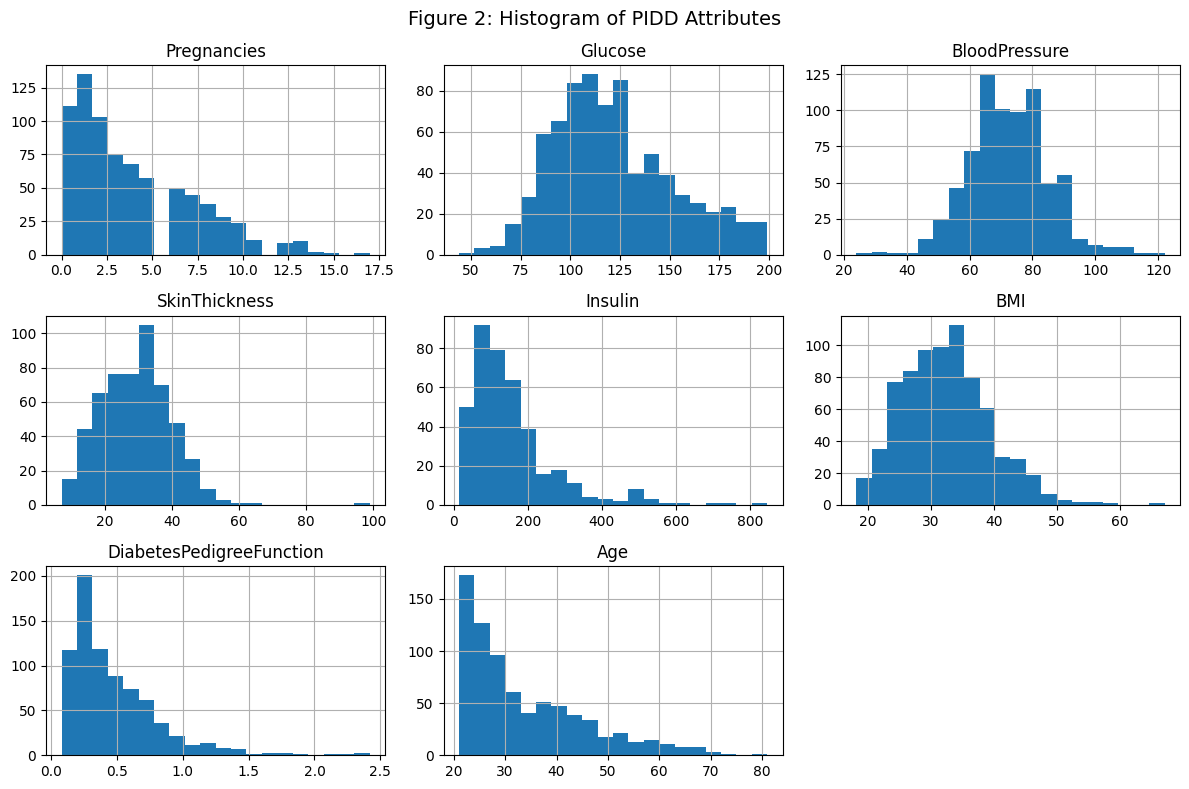

In [ ]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

df.drop('Outcome', axis=1).hist(bins=20, figsize=(12, 8))
plt.suptitle("Figure 2: Histogram of PIDD Attributes", fontsize=14)
plt.tight_layout()
plt.savefig("fig2_histograms.png", dpi=300)
plt.show()


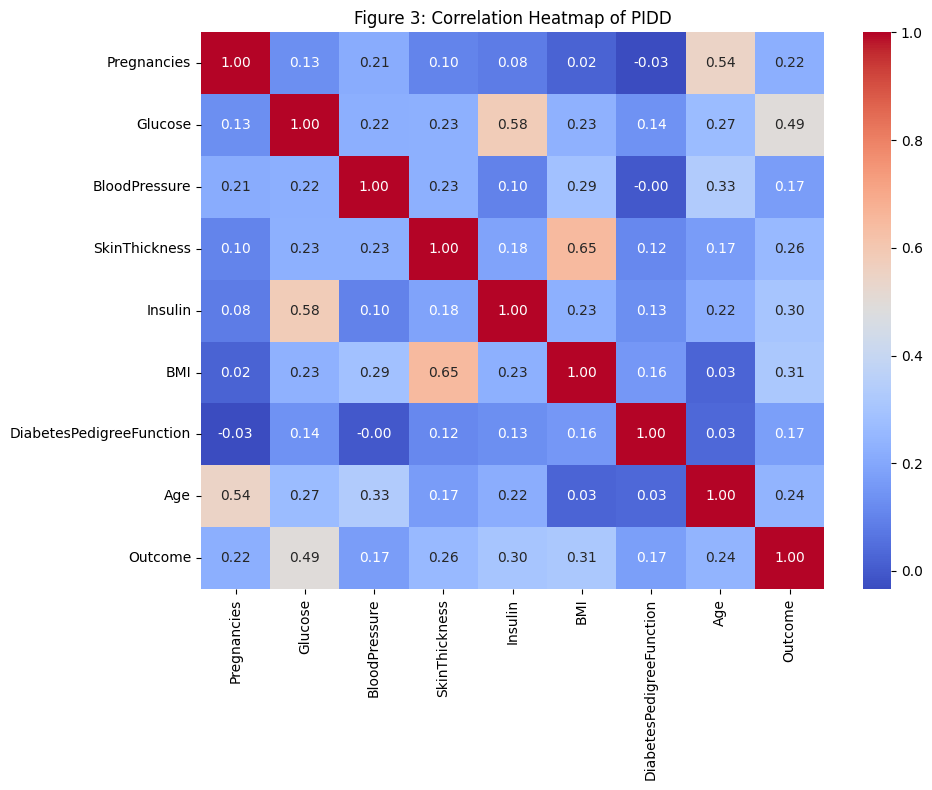

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Figure 3: Correlation Heatmap of PIDD")
plt.tight_layout()
plt.savefig("fig3_heatmap_pidd.png", dpi=300)
plt.show()


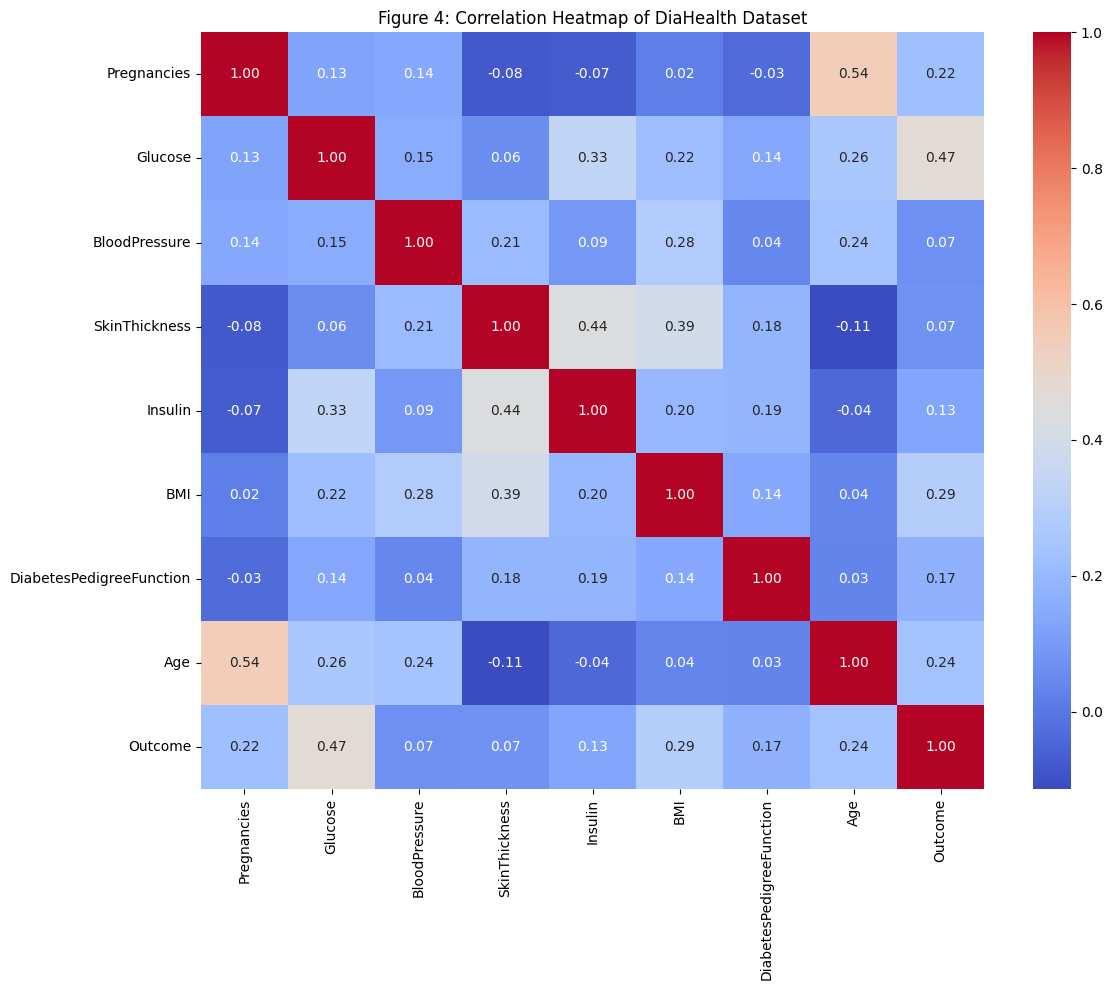

In [ ]:
dh = pd.read_csv("/content/diabetes (1).csv")


plt.figure(figsize=(12, 10))
sns.heatmap(dh.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Figure 4: Correlation Heatmap of DiaHealth Dataset")
plt.tight_layout()
plt.savefig("fig4_heatmap_diahealth.png", dpi=300)
plt.show()

In [ ]:
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

def remove_outliers_iqr(data):
    df_clean = data.copy()
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        if col == 'Outcome':
            continue
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]
    return df_clean

df_clean = remove_outliers_iqr(df_imputed)
print("Rows after cleaning:", len(df_clean))
print(df_clean['Outcome'].value_counts())



Rows after cleaning: 462
Outcome
0.0    302
1.0    160
Name: count, dtype: int64


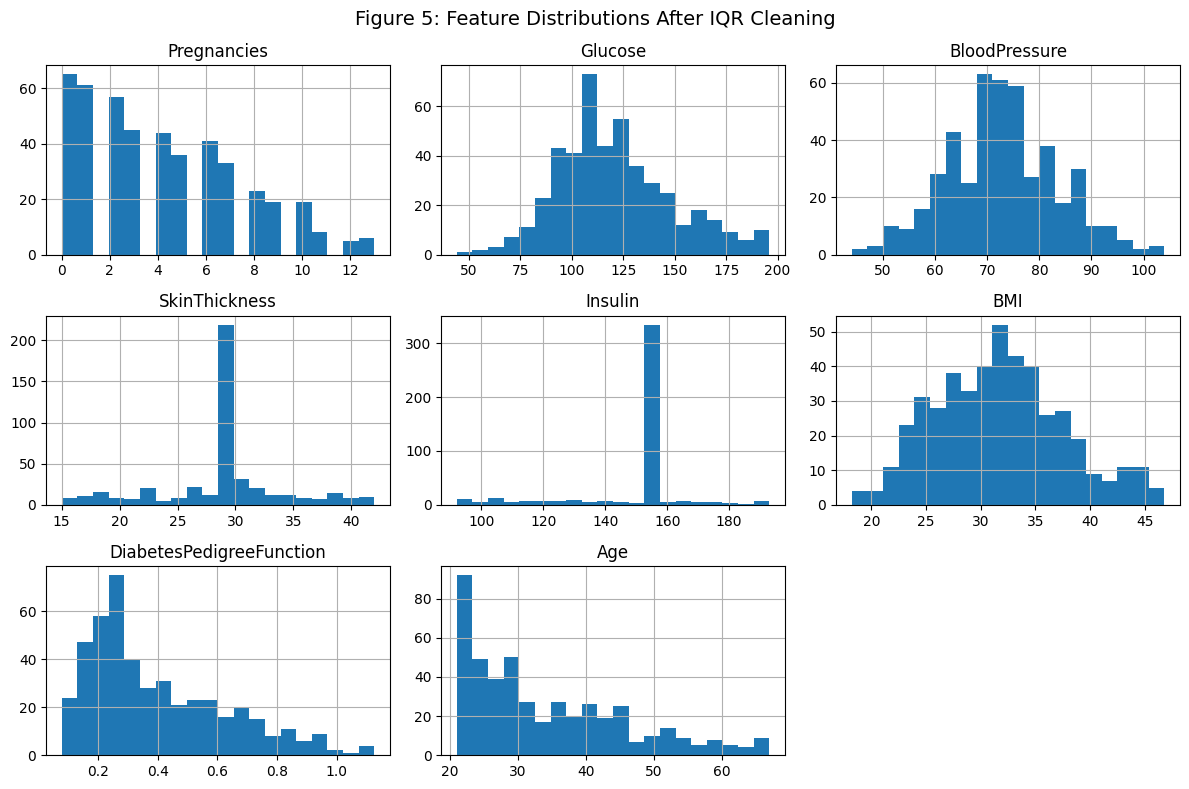

In [ ]:
df_clean.drop('Outcome', axis=1).hist(bins=20, figsize=(12, 8))
plt.suptitle("Figure 5: Feature Distributions After IQR Cleaning", fontsize=14)
plt.tight_layout()
plt.savefig("fig5_cleaned_distributions.png", dpi=300)
plt.show()


In [ ]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)
print("After oversampling:", pd.Series(y_resampled).value_counts())


X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.30, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


After oversampling: Outcome
1.0    302
0.0    302
Name: count, dtype: int64
Train: (422, 8), Test: (182, 8)


In [ ]:
X_raw = df.drop('Outcome', axis=1).fillna(0)
y_raw = df['Outcome']
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42)

for name, model in [
    ("XGBoost",  XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ("LightGBM", LGBMClassifier(random_state=42))
]:
    model.fit(X_tr, y_tr)
    p = model.predict(X_te)
    print(f"{name} Baseline → Acc: {accuracy_score(y_te,p):.4f} | F1: {f1_score(y_te,p):.4f}")
# XGBoost  → 0.7532 | LightGBM → 0.7359


XGBoost Baseline → Acc: 0.7143 | F1: 0.6250
[LightGBM] [Info] Number of positive: 188, number of negative: 349
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350093 -> initscore=-0.618630
[LightGBM] [Info] Start training from score -0.618630
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

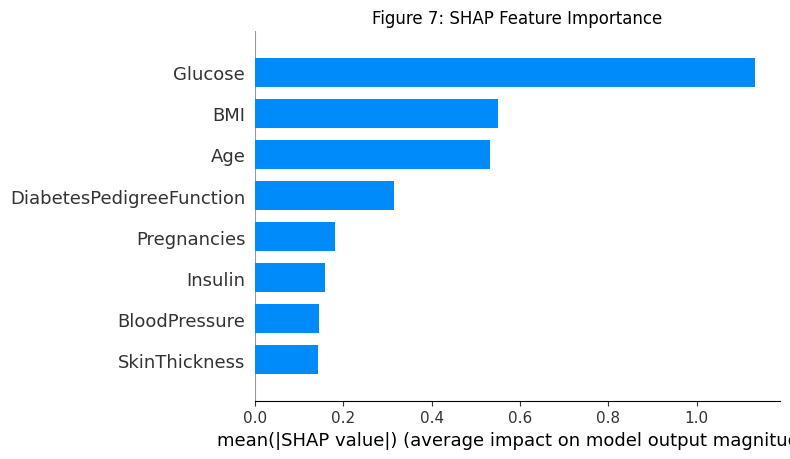

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_resampled, y_resampled)

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_resampled)

shap.summary_plot(shap_values, X_resampled, plot_type="bar", show=False)
plt.title("Figure 7: SHAP Feature Importance")
plt.tight_layout()
plt.savefig("fig7_shap.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
rfe = RFECV(estimator=GradientBoostingClassifier(random_state=42),
            step=1, cv=5, min_features_to_select=1, scoring='accuracy')
rfe.fit(X_resampled, y_resampled)
rfe_features = list(X_resampled.columns[rfe.support_])
print("RFE Selected Features:", rfe_features)


RFE Selected Features: ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
from boruta import BorutaPy

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_selected = []

for train_idx, _ in skf.split(X_resampled, y_resampled):
    X_fold = X_resampled.iloc[train_idx].values
    y_fold = y_resampled.iloc[train_idx].values.astype(int)
    rf = RandomForestClassifier(n_jobs=-1, random_state=42)
    boruta = BorutaPy(rf, n_estimators='auto', random_state=42, verbose=0)
    boruta.fit(X_fold, y_fold)
    all_selected.append([i for i, s in enumerate(boruta.support_) if s])

flat = [f for fold in all_selected for f in fold]
top5 = [f for f, _ in Counter(flat).most_common(5)]
boruta_features = list(X_resampled.columns[top5])
print("Boruta Selected Features:", boruta_features)
# Expected: Glucose, SkinThickness, BMI, DiabetesPedigreeFunction, Age


Boruta Selected Features: ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BloodPressure']


In [ ]:
feature_sets = {"Boruta": boruta_features, "RFE": rfe_features}
final_models = {}

for fsa, feats in feature_sets.items():
    for clf_name, clf in [
        ("XGBoost",  XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')),
        ("LightGBM", LGBMClassifier(random_state=42))
    ]:
        start = time.time()
        clf.fit(X_train[feats], y_train)
        t = time.time() - start
        preds = clf.predict(X_test[feats])
        print(f"{fsa}+{clf_name} → Acc:{accuracy_score(y_test,preds)*100:.2f}% "
              f"F1:{f1_score(y_test,preds,average='macro'):.4f} Time:{t:.4f}s")
        final_models[f"{fsa}_{clf_name}"] = (clf, feats)


Boruta+XGBoost → Acc:78.02% F1:0.7796 Time:1.5249s
[LightGBM] [Info] Number of positive: 204, number of negative: 218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 422, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483412 -> initscore=-0.066375
[LightGBM] [Info] Start training from score -0.066375
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

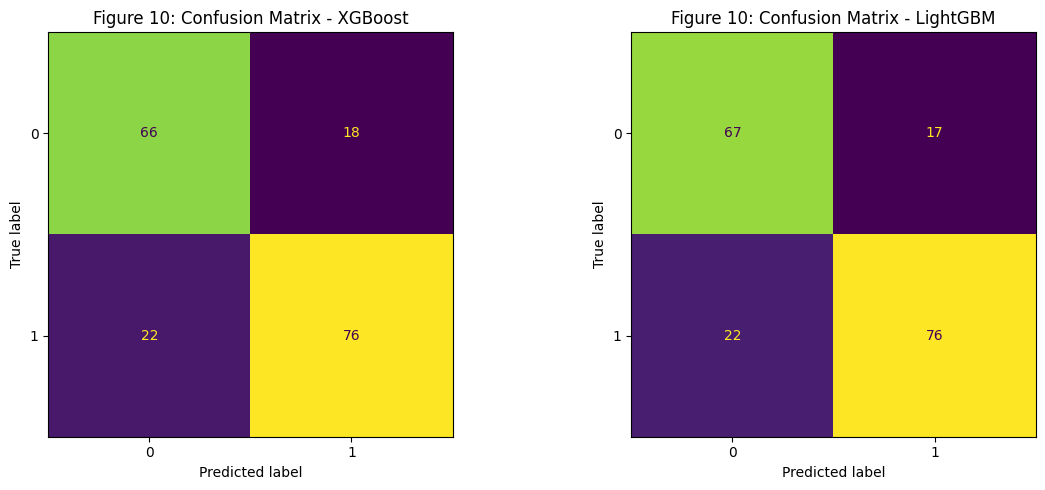

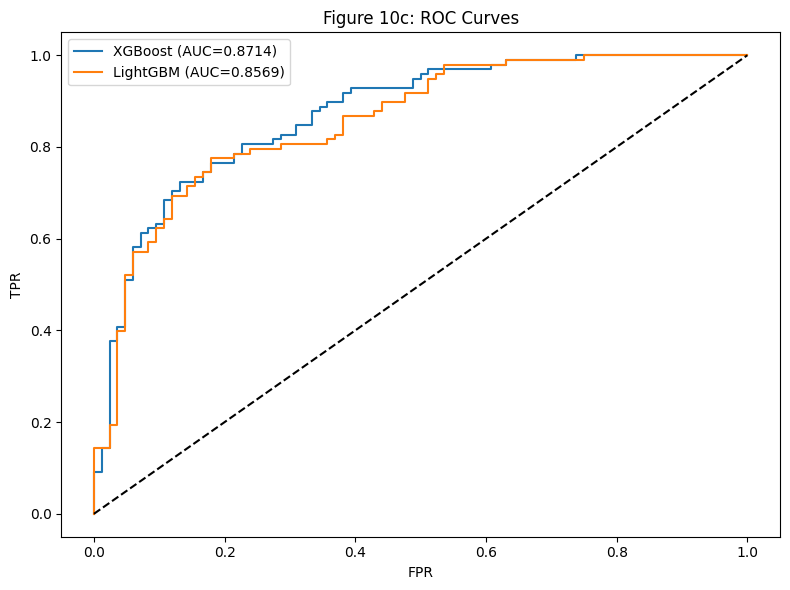

In [ ]:
xgb_m, xgb_f = final_models["Boruta_XGBoost"]
lgbm_m, lgbm_f = final_models["Boruta_LightGBM"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, m, f) in zip(axes, [("XGBoost", xgb_m, xgb_f), ("LightGBM", lgbm_m, lgbm_f)]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, m.predict(X_test[f]))).plot(ax=ax, colorbar=False)
    ax.set_title(f"Figure 10: Confusion Matrix - {name}")
plt.tight_layout()
plt.savefig("fig10ab_confusion.png", dpi=300)
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
for name, m, f in [("XGBoost", xgb_m, xgb_f), ("LightGBM", lgbm_m, lgbm_f)]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test[f])[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Figure 10c: ROC Curves")
plt.legend(); plt.tight_layout()
plt.savefig("fig10c_roc.png", dpi=300)
plt.show()
# Expected: LightGBM AUC ≈ 0.9052


In [ ]:
from google.colab import files
import os

for f in os.listdir():
    if f.endswith(".png"):
        files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>